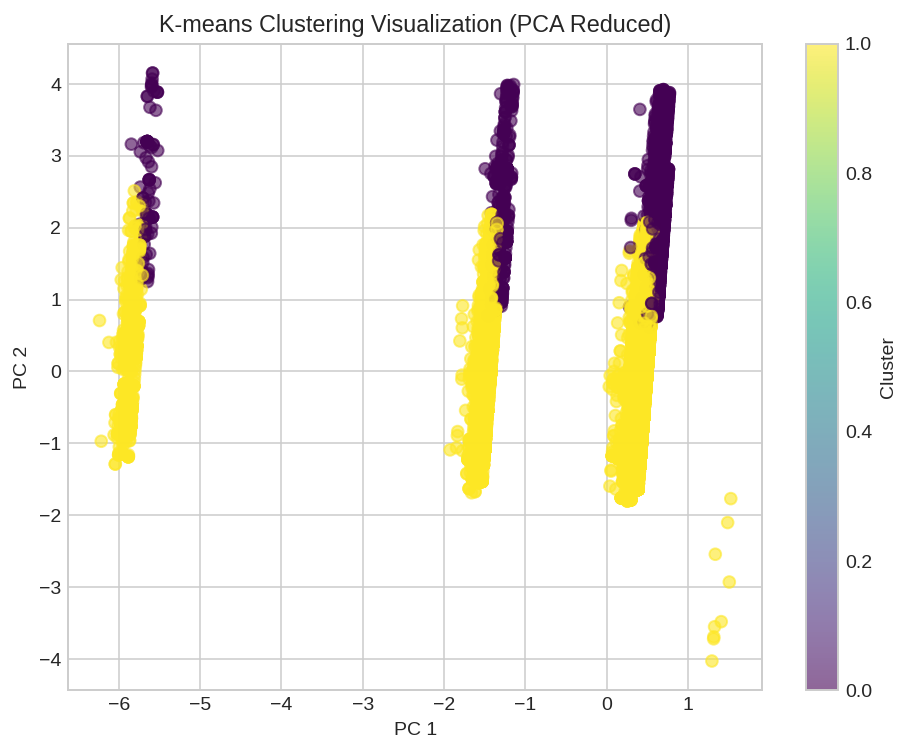

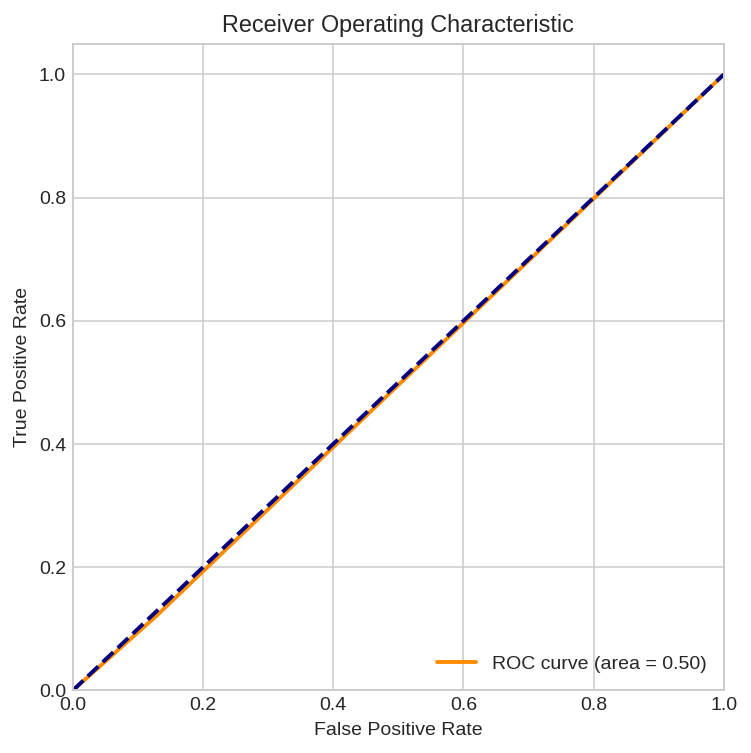

Accuracy: 0.7525666666666667
Confusion Matrix:
 [[22003  3202]
 [ 4221   574]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86     25205
           1       0.15      0.12      0.13      4795

    accuracy                           0.75     30000
   macro avg       0.50      0.50      0.49     30000
weighted avg       0.73      0.75      0.74     30000



In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import numpy as np

file_path = r"cbedatafinal2.csv"
dataframe = pd.read_csv(file_path)
dataframe = dataframe.dropna()

label_encoder = LabelEncoder()
y_raw = dataframe['churn']
y = label_encoder.fit_transform(y_raw)

columns_to_drop = ["OPENING_DATE", "AccountNumber", "Tenure", "current balance", "TXN_AMOUNT", "churn"]
features = dataframe.drop(columns=columns_to_drop, errors='ignore')

categorical_features = ["type of account", "INACTIVE", "Mobile user", "has ATM CARD", "CURRENCY", "Job type", "GENDER"]
X = pd.get_dummies(features, columns=categorical_features, drop_first=True, dtype=int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 2

kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Map clusters to match actual labels as closely as possible
cm = confusion_matrix(y, clusters)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = dict(zip(col_ind, row_ind))
mapped_clusters = np.array([mapping[label] for label in clusters])

accuracy = accuracy_score(y, mapped_clusters)
conf_mat = confusion_matrix(y, mapped_clusters)
class_report = classification_report(y, mapped_clusters)

fpr, tpr, _ = roc_curve(y, mapped_clusters)
roc_auc = auc(fpr, tpr)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("K-means Clustering Visualization (PCA Reduced)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_mat)
print("Classification Report:\n", class_report)